# Notebook amélioré — Prédiction de `business_domain`

Pipeline optimisé pour la prédiction du domaine métier d'assets de données
(tables Oracle / enregistrements PeopleSoft) à partir de leurs métadonnées.

## Problèmes corrigés vs. version initiale
1. **Fuites de données éliminées** : `business_domain_raw`, `llm_votes_json`,
   `llm_consensus_score`, `llm_models_used`, `llm_prompt_version`, `llm_status`
   étaient présents dans le DataFrame et non tous exclus. `business_domain_raw`
   est un mapping 1:1 vers la cible (fuite catastrophique).
2. **Qualité des labels** : filtrage / pondération optionnels via
   `llm_consensus_score` (les labels LLM à faible consensus sont bruités).
3. **Déséquilibre des classes** : `Ventes & Clients` ≈ 1.7 %, `Finance` ≈ 37 %.
   On garde `class_weight='balanced'` mais on ajoute un poids par échantillon
   issu du consensus LLM.
4. **Features** : ajout de préfixes/suffixes de `technical_name`, enrichissement
   du vocabulaire clé métier, texte concaténé pour TF-IDF global.
5. **Représentation texte** : **TF-IDF sparse direct** (sans SVD) pour les
   modèles linéaires et LightGBM — la compression SVD perd beaucoup
   d'information sur du texte court et structuré.
6. **Évaluation** : CV stratifiée 5 folds (moyenne ± écart-type), rapport
   par classe, matrice de confusion, analyse des erreurs ciblée.
7. **Scalabilité (~500 k lignes)** : dtypes optimisés, TF-IDF + `HashingVectorizer`
   disponible en fallback, LightGBM sur sparse, chronométrage par étape.

## Plan
1. Chargement + audit qualité labels
2. Nettoyage ciblé et retrait des fuites
3. Feature engineering (structurel + préfixes + mots-clés métier)
4. Représentations texte (TF-IDF char + word, sparse)
5. Baseline linéaire (Logistic Regression)
6. LightGBM sur sparse
7. Évaluation CV stratifiée + analyse d'erreurs
8. Sauvegarde du pipeline complet


## 1. Setup

In [22]:
# Dépendances
import importlib, subprocess, sys

REQUIRED = ["lightgbm", "joblib", "scipy", "scikit-learn", "pandas", "numpy", "matplotlib"]
for pkg in REQUIRED:
    name = pkg.replace("-", "_")
    try:
        importlib.import_module(name if name != "scikit_learn" else "sklearn")
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("Dépendances prêtes.")


Dépendances prêtes.


In [23]:
import os
import re
import json
import time
import warnings
from pathlib import Path
from contextlib import contextmanager

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

from scipy.sparse import hstack, csr_matrix, vstack
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
 )
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, HashingVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from lightgbm import LGBMClassifier
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

@contextmanager
def timer(label):
    t0 = time.perf_counter()
    yield
    print(f"[{label}] {time.perf_counter() - t0:.2f}s")


## 2. Configuration

Toutes les options du pipeline sont centralisées ici.

In [24]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_FOLDS = 5
TARGET = "business_domain"

# --- Fichier source ---
# Place le CSV a cote du notebook ou modifie DATA_FILENAME.
DATA_FILENAME = r"C:\Users\Salem\Desktop\Projets\pfe\Projet\exports\dataset_asset_ml_training_v5_remapped.csv"

# --- Qualite des labels (labels LLM-genere, bruit possible) ---
# None  => utiliser toutes les lignes
# float => filtrer les lignes avec llm_consensus_score < seuil
MIN_CONSENSUS_FILTER = None      # ex: 0.6 pour drop les tres faibles
USE_CONSENSUS_AS_WEIGHT = True   # pondere l'entrainement par la confiance LLM

# --- Colonnes a exclure ---
# 1) identifiants techniques (non informatifs, risque d'overfit)
# 2) FUITES : toutes les colonnes derivees du processus de labeling LLM
LEAK_COLS = [
    "business_domain_raw",   # mapping 1:1 quasi-parfait vers la cible
    "business_domain_label", # colonne parent legacy
    "labeling_notes",
    "llm_votes_json",
    "llm_consensus_score",   # extrait separement pour le weighting
    "llm_models_used",
    "llm_prompt_version",
    "llm_status",
    "confidence",
    "reason",
]
ID_COLS = ["run_id", "asset_id"]
DROP_COLS = LEAK_COLS + ID_COLS

# --- Features ---
TEXT_COLS_CHAR = ["technical_name", "source_ref"]
TEXT_COLS_WORD = [
    "column_names_text",
    "column_type_signature_text",
    "column_value_semantics_text",
    "column_sample_values_text",
    "column_observed_pattern_text",
]
NUM_COLS = [
    "field_count", "nullable_field_count", "non_nullable_field_count",
    "numeric_field_count", "date_field_count", "text_field_count",
    "large_text_field_count", "avg_data_length", "max_data_length",
    "row_count", "size_bytes", "size_mb",
]
CAT_COLS = ["source_system", "asset_type", "has_profile_data"]

# --- Parametres vectorisation ---
CHAR_MAX_FEATURES = 50_000
WORD_MAX_FEATURES = 80_000
CHAR_NGRAMS = (3, 5)
WORD_NGRAMS = (1, 2)
USE_HASHING_FOR_SCALE = False   # True si > ~200k lignes et RAM limitee

# --- Modeles actifs ---
RUN_LOGREG = True
RUN_LINSVC = True
RUN_LIGHTGBM = True
RUN_CV = True     # CV stratifiee 5 folds (desactive si uniquement POC rapide)

# --- Production et audit ---
PROD_SELECTION_SOURCE = "cv"     # "cv" recommande pour plus de stabilite
FORCE_PROD_MODEL = None           # ex: "LinearSVC", "LogReg", "LightGBM"
CALIBRATE_LINSVC_FOR_PROD = True
CONFIDENCE_LOW_THRESHOLD = 0.60
CONFIDENCE_MED_THRESHOLD = 0.80
BORDERLINE_MARGIN_THRESHOLD = 0.15
RARE_CLASS_MAX_RATIO = 0.05
REVIEW_TOP_N = 500

print("Config chargee.")


Config chargee.


## 3. Chargement et audit rapide

In [25]:
def resolve_data_path(filename: str) -> Path:
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path("/mnt/data") / filename,
        Path("/content") / filename,
        Path("/mnt/user-data/uploads") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"CSV introuvable : {filename}")

DATA_PATH = resolve_data_path(DATA_FILENAME)
print("DATA_PATH =", DATA_PATH)

# Astuce scalabilité : spécifier les dtypes évite les warnings et
# accélère le parsing. Pour 500 k lignes, penser à `usecols`.
dtype_hint = {
    "source_system": "category",
    "asset_type": "category",
    "has_profile_data": "boolean",
    "field_count": "Int32",
    "nullable_field_count": "Int32",
    "non_nullable_field_count": "Int32",
    "numeric_field_count": "Int32",
    "date_field_count": "Int32",
    "text_field_count": "Int32",
    "large_text_field_count": "Int32",
    "max_data_length": "Int32",
    "avg_data_length": "float32",
    "row_count": "float32",
    "size_bytes": "float64",
    "size_mb": "float32",
    "llm_consensus_score": "float32",
}

with timer("read_csv"):
    df_raw = pd.read_csv(
        DATA_PATH,
        sep=";",
        encoding="cp1252",
        na_values=["", "NA", "null", "None"],
        true_values=["VRAI", "True", "true", "1"],
        false_values=["FAUX", "False", "false", "0"],
        on_bad_lines="skip"
    )  
print("Shape :", df_raw.shape)
print("Memory (MB) :", round(df_raw.memory_usage(deep=True).sum() / 1e6, 1))
df_raw.head(2)


DATA_PATH = C:\Users\Salem\Desktop\Projets\pfe\Projet\exports\dataset_asset_ml_training_v5_remapped.csv
[read_csv] 0.58s
Shape : (19280, 32)
Memory (MB) : 49.9


,run_id,asset_id,source_system,asset_type,technical_name,source_ref,field_count,nullable_field_count,non_nullable_field_count,numeric_field_count,date_field_count,text_field_count,large_text_field_count,avg_data_length,max_data_length,row_count,size_bytes,size_mb,has_profile_data,column_names_text,column_type_signature_text,column_value_semantics_text,column_sample_values_text,column_observed_pattern_text,business_domain_label,labeling_notes,business_domain,confidence,reason,remap_status,needs_review,ps_prefix
0,5.0,1004281.0,oracle,oracle_table,SYSADM.PS_ACCESS_GRP_TBL,PS_ACCESS_GRP_TBL,3.0,1.0,2.0,0.0,0.0,3.0,1.0,16.666667,30.0,525.0,40425.0,0.038552,True,ACCESS_GROUP | DESCR | DESCRLONG,ACCESS_GROUP:VARCHAR2 | DESCR:VARCHAR2 | DESCR...,ACCESS_GROUP:classification | DESCR:label | DE...,ACCESS_GROUP:[ACCOUNT DISTRIBUTION | ACCOUNTIN...,ACCESS_GROUP:short_code_like | DESCR:free_text...,NaN,NaN,IT & Technique,0.8,The table name 'PS_ACCESS_GRP_TBL' and column ...,remap_direct,False,ACCESS
1,5.0,1004286.0,oracle,oracle_table,SYSADM.PS_ACCOMPLISH_LANG,PS_ACCOMPLISH_LANG,12.0,1.0,11.0,0.0,1.0,11.0,0.0,19.333333,50.0,0.0,0.0,0.000000,True,ACCOMPLISHMENT | DT_ISSUED | EDUCATOR | EMPLID...,ACCOMPLISHMENT:VARCHAR2 | DT_ISSUED:DATE | EDU...,ACCOMPLISHMENT:label | DT_ISSUED:date_or_times...,NaN,NaN,NaN,NaN,RH & Paie,0.8,The table contains columns with semantic patte...,remap_direct,False,ACCOMPLISH


In [26]:
# --- Audit cible et qualité labels ---
print("\n=== Distribution business_domain ===")
target_counts = df_raw[TARGET].value_counts(dropna=False)
print(target_counts)
print(f"\nRatio déséquilibre max/min : {target_counts.max() / target_counts.min():.1f}x")

print("\n=== llm_consensus_score ===")
print(df_raw["llm_consensus_score"].describe())

print("\n=== Lignes à faible consensus par classe (< 0.8) ===")
low_conf = df_raw[df_raw["llm_consensus_score"] < 0.8]
print(f"Total : {len(low_conf)} ({100*len(low_conf)/len(df_raw):.1f}%)")
print(low_conf[TARGET].value_counts())

# Preuve de la fuite business_domain_raw -> business_domain (si colonne présente)
if "business_domain_raw" in df_raw.columns:
    print("\n=== Mapping raw -> clean (preuve de fuite) ===")
    mp = df_raw.groupby("business_domain_raw")[TARGET].agg(
        lambda s: s.value_counts().index[0])
    print(mp)
    print("=> business_domain_raw est un mapping ~1:1 vers la cible => MUST DROP")



=== Distribution business_domain ===
business_domain
Finance & Comptabilité         5550
IT & Technique                 4488
RH & Paie                      3146
Achats & Approvisionnement     2631
Gestion de Projets & Actifs    2164
Supply Chain & Ventes          1288
NaN                              13
Name: count, dtype: int64

Ratio déséquilibre max/min : 426.9x

=== llm_consensus_score ===


KeyError: 'llm_consensus_score'

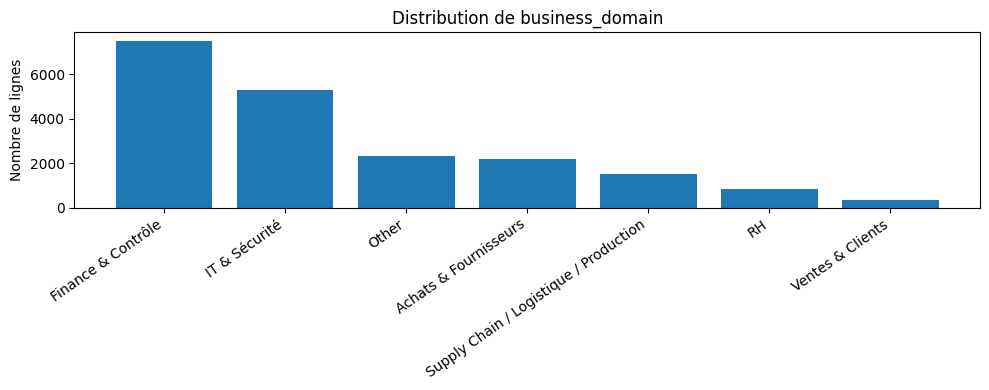

In [ ]:
# --- Visualisation cible ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(target_counts.index.astype(str), target_counts.values)
ax.set_xticklabels(target_counts.index.astype(str), rotation=35, ha="right")
ax.set_title("Distribution de business_domain")
ax.set_ylabel("Nombre de lignes")
plt.tight_layout()
plt.show()


## 4. Qualité des labels

Les labels ont été produits par un LLM (multi-votes). Deux stratégies
défensives :

- **Filtrage** (`MIN_CONSENSUS_FILTER`) : on retire les lignes à très faible
  consensus (par défaut désactivé pour ne pas perdre de signal sur les
  classes minoritaires).
- **Pondération** (`USE_CONSENSUS_AS_WEIGHT`) : `sample_weight` = consensus,
  donc les lignes certaines pèsent plus que les lignes douteuses.

In [ ]:
def apply_label_quality_gate(df: pd.DataFrame) -> pd.DataFrame:
    n0 = len(df)
    if MIN_CONSENSUS_FILTER is not None and "llm_consensus_score" in df.columns:
        df = df[df["llm_consensus_score"] >= MIN_CONSENSUS_FILTER].copy()
        print(f"Filtrage consensus >= {MIN_CONSENSUS_FILTER} : {n0} -> {len(df)}"
              f" ({100*(n0-len(df))/n0:.1f}% retirés)")

    # On conserve `llm_consensus_score` TEMPORAIREMENT pour la pondération,
    # puis on la retire avant la modélisation (voir plus bas).
    return df

df_gated = apply_label_quality_gate(df_raw)
print("Shape après gate :", df_gated.shape)


Shape après gate : (20000, 33)


## 5. Preprocessing & feature engineering

### Principes
- Retirer identifiants techniques et colonnes fuite
- Normaliser les textes (lowercase + séparateurs)
- Extraire des signaux structurels (ratios, logs)
- Extraire des **préfixes/suffixes de `technical_name`** — hyper informatifs
  (ex : `PS_GL_*` ⇒ Finance, `PS_HR_*` ⇒ RH)
- Compteurs de mots-clés métier enrichis

In [ ]:
# --- Lexiques métier enrichis (EN + FR + codes PeopleSoft courants) ---
DOMAIN_KEYWORDS = {
    "finance": [
        "invoice", "payment", "ledger", "gl", "tax", "budget", "amount",
        "cost", "expense", "revenue", "accounting", "journal", "account",
        "ap", "ar", "fi", "glacct", "treasur", "asset", "deprec",
        "facture", "paiement", "comptabil", "compte", "montant", "devise",
        "currency", "vat", "tva",
    ],
    "hr": [
        "employee", "empl", "emplid", "job", "manager", "payroll", "absence",
        "position", "hire", "worker", "salary", "person", "headcount",
        "compensation", "benefit", "pay", "leave", "employe", "salaire",
        "poste", "absence", "conge",
    ],
    "it": [
        "user", "role", "access", "auth", "permission", "config", "server",
        "system", "account", "login", "application", "security", "sysadm",
        "menu", "page", "xlat", "dbowner", "portal", "prcs", "audit",
        "log_", "log",
    ],
    "procurement": [
        "vendor", "supplier", "purchase", "po_", "item", "stock", "inventory",
        "material", "order", "sourcing", "rfq", "contract",
        "fournisseur", "achat", "commande", "stock",
    ],
    "sales": [
        "customer", "client", "opportunity", "quote", "deal", "crm",
        "sales", "pipeline", "booking", "cust_", "cust",
        "vente", "facturation",
    ],
    "marketing": [
        "campaign", "lead", "segment", "channel", "audience", "click",
        "impression", "conversion", "promo",
    ],
    "risk": [
        "risk", "control", "audit", "incident", "compliance", "issue",
        "mitigation", "policy", "controle", "conformite",
    ],
    "supply_chain": [
        "shipment", "warehouse", "inventory", "delivery", "route",
        "transport", "plant", "logistics", "bom", "prod_",
        "livraison", "entrepot", "logistique", "production",
    ],
}

# Préfixes PeopleSoft courants (source : documentation PS)
PS_MODULE_PREFIXES = {
    "GL": "finance", "AP": "finance", "AR": "finance", "AM": "finance",
    "BI": "finance", "TR": "finance", "EX": "finance",
    "HR": "hr", "JOB": "hr", "PERSON": "hr", "BEN": "hr", "PAY": "hr",
    "ABS": "hr", "COMP": "hr",
    "PO": "procurement", "EP": "procurement", "RFQ": "procurement",
    "CON": "procurement", "VND": "procurement",
    "IN": "supply_chain", "PL": "supply_chain", "SF": "supply_chain",
    "MG": "supply_chain", "PROD": "supply_chain",
    "SA": "sales", "OM": "sales", "CRM": "sales",
    "PRCS": "it", "PSAUTH": "it", "PSOPR": "it", "PSROLE": "it",
    "PT": "it", "PSMENU": "it",
}

def normalize_text(x) -> str:
    if pd.isna(x):
        return ""
    x = str(x).lower()
    for sep in ["_", "-", "|", "/", "\\", ".", ":", ";", ",",
                "(", ")", "[", "]", "{", "}"]:
        x = x.replace(sep, " ")
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def safe_div(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    return np.divide(a, b, out=np.zeros_like(a, dtype=np.float32), where=b != 0)


In [ ]:
def extract_prefix(tname: str) -> str:
    """Extrait le préfixe métier depuis un nom technique PeopleSoft.
    Ex : 'SYSADM.PS_GL_ACCOUNT' -> 'GL'
         'PS_HR_EMPL_JOB'        -> 'HR'
    """
    if not isinstance(tname, str):
        return ""
    # retire schéma et préfixe PS_
    s = tname.upper()
    s = re.sub(r"^[A-Z]+\.", "", s)          # retire SYSADM.
    s = re.sub(r"^PS[_]?", "", s)              # retire PS ou PS_
    m = re.match(r"([A-Z]+)_", s)
    return m.group(1) if m else s.split("_")[0][:6]

def build_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)

    # --- Ratios structurels ---
    field_count = df["field_count"].fillna(0).astype(np.float32).values
    out["ratio_numeric"]      = safe_div(df["numeric_field_count"].fillna(0), field_count)
    out["ratio_date"]         = safe_div(df["date_field_count"].fillna(0), field_count)
    out["ratio_text"]         = safe_div(df["text_field_count"].fillna(0), field_count)
    out["ratio_large_text"]   = safe_div(df["large_text_field_count"].fillna(0), field_count)
    out["ratio_nullable"]     = safe_div(df["nullable_field_count"].fillna(0), field_count)
    out["ratio_non_nullable"] = safe_div(df["non_nullable_field_count"].fillna(0), field_count)

    # --- Logs (distributions très skewed) ---
    for c in ["row_count", "size_bytes", "size_mb", "avg_data_length", "max_data_length"]:
        out[f"log_{c}"] = np.log1p(df[c].fillna(0).astype(np.float32))

    out["avg_size_per_field"] = safe_div(df["size_bytes"].fillna(0),
                                         np.maximum(field_count, 1))

    # --- Features de forme sur noms techniques ---
    for prefix in ["technical_name", "source_ref"]:
        s = df[prefix].fillna("").astype(str)
        out[f"{prefix}_len"]              = s.str.len().astype(np.Int32)
        out[f"{prefix}_token_count"]      = s.str.count(r"[A-Za-z0-9]+").astype(np.Int32)
        out[f"{prefix}_digit_count"]      = s.str.count(r"\d").astype(np.Int32)
        out[f"{prefix}_underscore_count"] = s.str.count(r"_").astype(np.Int32)
        # upper_ratio vectorisé (évite apply)
        total = s.str.len().replace(0, 1)
        upper = s.str.count(r"[A-Z]")
        out[f"{prefix}_upper_ratio"] = (upper / total).astype(np.float32)
        out[f"{prefix}_has_id"]  = s.str.contains(r"id",       case=False, regex=True).astype(np.int8)
        out[f"{prefix}_has_dt"]  = s.str.contains(r"dt|date",  case=False, regex=True).astype(np.int8)
        out[f"{prefix}_has_amt"] = s.str.contains(r"amt|amount", case=False, regex=True).astype(np.int8)
        out[f"{prefix}_has_cd"]  = s.str.contains(r"cd|code",  case=False, regex=True).astype(np.int8)

    # --- Préfixe module PS (signal très fort) ---
    if "technical_name" in df.columns:
        prefixes = df["technical_name"].apply(extract_prefix)
        out["ps_prefix"] = prefixes
        # indicateurs one-hot sur les modules connus
        for mod in sorted(set(PS_MODULE_PREFIXES.keys())):
            out[f"ps_is_{mod}"] = (prefixes == mod).astype(np.int8)

    # --- Keyword counts métier ---
    combined = (
        df["technical_name"].fillna("").astype(str) + " " +
        df["source_ref"].fillna("").astype(str) + " " +
        df["column_names_text"].fillna("").astype(str) + " " +
        df["column_value_semantics_text"].fillna("").astype(str)
    ).str.lower()

    for domain, keywords in DOMAIN_KEYWORDS.items():
        pattern = r"\b(" + "|".join(re.escape(k) for k in keywords) + r")\b"
        c = combined.str.count(pattern).astype(np.int16)
        out[f"{domain}_keyword_count"] = c
        out[f"has_{domain}_keyword"]   = (c > 0).astype(np.int8)

    return out.fillna(0)

def prepare_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Normalisation texte
    for col in TEXT_COLS_CHAR + TEXT_COLS_WORD:
        if col in df.columns:
            df[col] = df[col].apply(normalize_text)
    # Catégorielles -> str
    for col in CAT_COLS:
        if col in df.columns:
            df[col] = df[col].astype(str).fillna("missing")
    # Numériques
    for col in NUM_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0).astype(np.float32)
    df[TARGET] = df[TARGET].astype(str)
    return df


In [ ]:
# Extraction des poids AVANT de drop les colonnes fuite
if USE_CONSENSUS_AS_WEIGHT and "llm_consensus_score" in df_gated.columns:
    sample_weights_all = df_gated["llm_consensus_score"].fillna(1.0).astype(np.float32).values
else:
    sample_weights_all = np.ones(len(df_gated), dtype=np.float32)

# Drop des fuites + IDs
present_drop = [c for c in DROP_COLS if c in df_gated.columns]
print("Colonnes retirées (fuites + IDs) :", present_drop)
df_clean = df_gated.drop(columns=present_drop)

with timer("prepare_dataframe"):
    df = prepare_dataframe(df_clean)

print("Shape après préparation :", df.shape)
print("Classes :", sorted(df[TARGET].unique()))


Colonnes retirées (fuites + IDs) : ['business_domain_raw', 'business_domain_label', 'labeling_notes', 'llm_votes_json', 'llm_consensus_score', 'llm_models_used', 'llm_prompt_version', 'llm_status', 'run_id', 'asset_id']
[prepare_dataframe] 4.49s
Shape après préparation : (20000, 23)
Classes : ['Achats & Fournisseurs', 'Finance & Contrôle', 'IT & Sécurité', 'Other', 'RH', 'Supply Chain / Logistique / Production', 'Ventes & Clients']


## 6. Split train / test stratifié

On stratifie pour préserver la distribution des classes minoritaires
(`Ventes & Clients` ≈ 1.7 %).

In [ ]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(str)

label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y_enc, sample_weights_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_enc,
)

print("Train :", X_train.shape, "Test :", X_test.shape)
print("Weight stats train : mean={:.3f} min={:.3f} max={:.3f}".format(
    w_train.mean(), w_train.min(), w_train.max()))
print("Classes :", list(label_encoder.classes_))


Train : (16000, 22) Test : (4000, 22)
Weight stats train : mean=0.962 min=0.500 max=1.000
Classes : ['Achats & Fournisseurs', 'Finance & Contrôle', 'IT & Sécurité', 'Other', 'RH', 'Supply Chain / Logistique / Production', 'Ventes & Clients']


## 7. Représentation texte — TF-IDF sparse (sans SVD)

**Différence clé vs. version précédente** : on garde la représentation TF-IDF
en **sparse**, sans compression TruncatedSVD.

### Pourquoi ?
- Les textes sont courts et structurés (noms de colonnes, types) : la SVD
  compresse beaucoup d'information utile dans peu de composantes.
- LightGBM gère nativement les matrices sparse → pas besoin de densifier.
- Logistic Regression et LinearSVC sont spécifiquement conçus pour le sparse
  haute dimension.

### Option scalabilité
Pour 500 k lignes, activer `USE_HASHING_FOR_SCALE=True` utilise
`HashingVectorizer` (mémoire fixe, pas de vocabulaire à stocker).

In [ ]:
def fit_text_matrix(X_train, X_test, cols, analyzer, ngram_range,
                    max_features, use_hashing=False):
    """Concatène les colonnes indiquées en un seul champ texte, puis
    applique TF-IDF (ou HashingVectorizer en mode scale)."""
    train_text = X_train[cols].fillna("").astype(str).agg(" ".join, axis=1)
    test_text  = X_test[cols].fillna("").astype(str).agg(" ".join, axis=1)

    if use_hashing:
        vec = HashingVectorizer(
            analyzer=analyzer,
            ngram_range=ngram_range,
            n_features=max_features,
            alternate_sign=False,
            norm="l2",
        )
        Xtr = vec.transform(train_text)
        Xte = vec.transform(test_text)
        feat_names = [f"hash_{i}" for i in range(max_features)]
    else:
        vec = TfidfVectorizer(
            analyzer=analyzer,
            ngram_range=ngram_range,
            min_df=3,
            max_features=max_features,
            sublinear_tf=True,
            dtype=np.float32,
        )
        Xtr = vec.fit_transform(train_text)
        Xte = vec.transform(test_text)
        feat_names = vec.get_feature_names_out().tolist()
    return vec, Xtr, Xte, feat_names

with timer("TF-IDF char (technical_name + source_ref)"):
    char_vec, Xtr_char, Xte_char, names_char = fit_text_matrix(
        X_train, X_test,
        cols=TEXT_COLS_CHAR,
        analyzer="char_wb",
        ngram_range=CHAR_NGRAMS,
        max_features=CHAR_MAX_FEATURES,
        use_hashing=USE_HASHING_FOR_SCALE,
    )
print("Char TF-IDF :", Xtr_char.shape)

with timer("TF-IDF word (colonnes sémantiques)"):
    word_vec, Xtr_word, Xte_word, names_word = fit_text_matrix(
        X_train, X_test,
        cols=TEXT_COLS_WORD,
        analyzer="word",
        ngram_range=WORD_NGRAMS,
        max_features=WORD_MAX_FEATURES,
        use_hashing=USE_HASHING_FOR_SCALE,
    )
print("Word TF-IDF :", Xtr_word.shape)

char_feat = [f"char__{n}" for n in names_char]
word_feat = [f"word__{n}" for n in names_word]


[TF-IDF char (technical_name + source_ref)] 2.93s
Char TF-IDF : (16000, 15556)
[TF-IDF word (colonnes sémantiques)] 13.16s
Word TF-IDF : (16000, 63279)


## 8. Bloc tabulaire (numérique + catégoriel + engineered)

In [ ]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True, dtype=np.float32)

with timer("engineered features"):
    eng_train = build_engineered_features(X_train)
    eng_test  = build_engineered_features(X_test)

# ps_prefix est juste extrait pour info (utile pour GBM natif mais pas pour
# l'OHE : trop haute cardinalité -> explosion features + mémorisation).
# On garde les indicateurs `ps_is_*` dans engineered_features qui couvrent
# les modules PS connus sans exploser la dimension.
if "ps_prefix" in eng_train.columns:
    eng_train = eng_train.drop(columns=["ps_prefix"])
    eng_test  = eng_test.drop(columns=["ps_prefix"])

base_num_train = X_train[NUM_COLS].astype(np.float32)
base_num_test  = X_test[NUM_COLS].astype(np.float32)

# Assemblage numérique + engineered
num_train_df = pd.concat([base_num_train.reset_index(drop=True),
                          eng_train.reset_index(drop=True)], axis=1)
num_test_df  = pd.concat([base_num_test.reset_index(drop=True),
                          eng_test.reset_index(drop=True)], axis=1)

num_feat_names = list(num_train_df.columns)

# Scaling numérique : indispensable pour les modèles linéaires (LogReg/SVC)
# car log_size_bytes ~1e1 et ratios ~1e-2. TF-IDF est déjà L2-normalisé,
# OHE est 0/1, donc on scale uniquement le bloc numérique.
from sklearn.preprocessing import StandardScaler
num_scaler = StandardScaler(with_mean=False)  # with_mean=False pour compat sparse
num_train_scaled = num_scaler.fit_transform(num_train_df.values.astype(np.float32))
num_test_scaled  = num_scaler.transform(num_test_df.values.astype(np.float32))
Xtr_num = csr_matrix(num_train_scaled.astype(np.float32))
Xte_num = csr_matrix(num_test_scaled.astype(np.float32))

# Catégorielles : source_system, asset_type, has_profile_data
cat_frame_train = X_train[CAT_COLS].copy()
cat_frame_test  = X_test[CAT_COLS].copy()

ohe = make_one_hot_encoder()
Xtr_cat = ohe.fit_transform(cat_frame_train.astype(str))
Xte_cat = ohe.transform(cat_frame_test.astype(str))
cat_feat_names = list(ohe.get_feature_names_out(cat_frame_train.columns))

print("Num :", Xtr_num.shape, "| Cat :", Xtr_cat.shape)
print("Nb features numériques :", len(num_feat_names))
print("Nb features catégorielles (OHE) :", len(cat_feat_names))


[engineered features] 12.78s
Num : (16000, 91) | Cat : (16000, 5)
Nb features numériques : 91
Nb features catégorielles (OHE) : 5


## 9. Assemblage final (sparse)

In [ ]:
X_train_final = hstack([Xtr_char, Xtr_word, Xtr_num, Xtr_cat]).tocsr()
X_test_final  = hstack([Xte_char, Xte_word, Xte_num, Xte_cat]).tocsr()

all_feat_names = char_feat + word_feat + num_feat_names + cat_feat_names
assert X_train_final.shape[1] == len(all_feat_names), "Incohérence features"

print("X_train_final :", X_train_final.shape)
print("X_test_final  :", X_test_final.shape)
print("Sparsity train : {:.4f}".format(
    1 - X_train_final.nnz / np.prod(X_train_final.shape)))
print("Taille mémoire train (MB) : {:.1f}".format(
    (X_train_final.data.nbytes + X_train_final.indices.nbytes +
     X_train_final.indptr.nbytes) / 1e6))


X_train_final : (16000, 78931)
X_test_final  : (4000, 78931)
Sparsity train : 0.9975
Taille mémoire train (MB) : 25.4


## 10. Fonctions d'évaluation

In [ ]:
def evaluate_predictions(y_true, y_pred, label_encoder, model_name="model",
                         show_cm=True, sample_weight=None):
    macro = f1_score(y_true, y_pred, average="macro", sample_weight=sample_weight)
    weighted = f1_score(y_true, y_pred, average="weighted", sample_weight=sample_weight)
    print(f"{model_name}  Macro-F1={macro:.4f}  Weighted-F1={weighted:.4f}")

    report = classification_report(
        y_true, y_pred, target_names=label_encoder.classes_,
        digits=4, output_dict=True, zero_division=0,
    )
    report_df = pd.DataFrame(report).T
    try:
        from IPython.display import display
        display(report_df)
    except Exception:
        print(report_df)

    if show_cm:
        cm = confusion_matrix(y_true, y_pred)
        cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(cm_df.values, aspect="auto", cmap="Blues")
        ax.set_xticks(range(len(cm_df.columns)))
        ax.set_xticklabels(cm_df.columns, rotation=40, ha="right")
        ax.set_yticks(range(len(cm_df.index)))
        ax.set_yticklabels(cm_df.index)
        for i in range(cm_df.shape[0]):
            for j in range(cm_df.shape[1]):
                ax.text(j, i, int(cm_df.values[i, j]), ha="center", va="center",
                        color="white" if cm_df.values[i, j] > cm_df.values.max()/2 else "black",
                        fontsize=8)
        ax.set_title(f"Matrice de confusion — {model_name}")
        fig.colorbar(im)
        plt.tight_layout()
        plt.show()

    return {"model": model_name, "macro_f1": macro, "weighted_f1": weighted,
            "report": report_df}

def cv_evaluate(build_model_fn, X, y, n_splits=5, sample_weight=None,
                model_name="model", supports_sw=True):
    """CV stratifiée : renvoie macro/weighted F1 par fold."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    macros, weighteds = [], []
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr = X[tr_idx] if hasattr(X, "__getitem__") else X.iloc[tr_idx]
        X_va = X[va_idx] if hasattr(X, "__getitem__") else X.iloc[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]
        w_tr = sample_weight[tr_idx] if (sample_weight is not None and supports_sw) else None

        model = build_model_fn()
        if w_tr is not None:
            try:
                model.fit(X_tr, y_tr, sample_weight=w_tr)
            except TypeError:
                model.fit(X_tr, y_tr)
        else:
            model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        m = f1_score(y_va, pred, average="macro")
        w = f1_score(y_va, pred, average="weighted")
        macros.append(m); weighteds.append(w)
        print(f"  fold {fold}  macro={m:.4f}  weighted={w:.4f}")
    print(f"[{model_name}] macro = {np.mean(macros):.4f} ± {np.std(macros):.4f}"
          f" | weighted = {np.mean(weighteds):.4f} ± {np.std(weighteds):.4f}")
    return {"model": model_name, "macro_mean": float(np.mean(macros)),
            "macro_std": float(np.std(macros)),
            "weighted_mean": float(np.mean(weighteds)),
            "weighted_std": float(np.std(weighteds))}


## 11. Modèle 1 — Logistic Regression (baseline forte)

Sur TF-IDF sparse, une régression logistique one-vs-rest est souvent
très compétitive et beaucoup plus rapide que les gradient boosters.

[LogReg fit] 193.07s
[LogReg predict] 0.01s
LogisticRegression  Macro-F1=0.8343  Weighted-F1=0.8719


,precision,recall,f1-score,support
Achats & Fournisseurs,0.893665,0.912240,0.902857,433.00000
Finance & Contrôle,0.968659,0.884820,0.924843,1502.00000
IT & Sécurité,0.901961,0.823751,0.861084,1061.00000
Other,0.676223,0.864224,0.758751,464.00000
RH,0.742424,0.859649,0.796748,171.00000
Supply Chain / Logistique / Production,0.793003,0.906667,0.846034,300.00000
Ventes & Clients,0.686747,0.826087,0.750000,69.00000
accuracy,0.868750,0.868750,0.868750,0.86875
macro avg,0.808955,0.868205,0.834331,4000.00000
weighted avg,0.881218,0.868750,0.871882,4000.00000


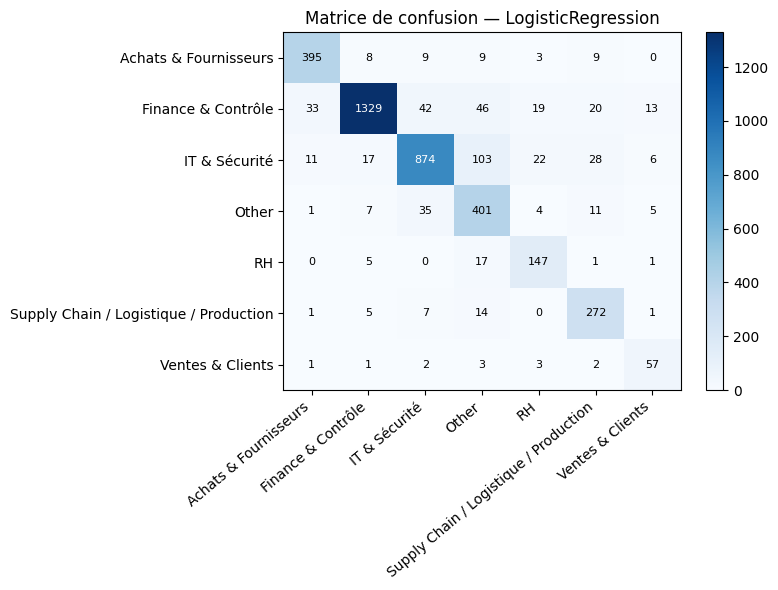

In [ ]:
results = []

if RUN_LOGREG:
    def make_logreg():
        # lbfgs : multiclass multinomial, support sparse, converge rapidement.
        # Pour très gros volumes (500 k), `saga` avec StandardScaler peut être
        # plus efficace, mais demande plus d'itérations.
        return LogisticRegression(
            C=2.0,
            max_iter=1000,
            class_weight="balanced",
            solver="lbfgs",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

    with timer("LogReg fit"):
        logreg = make_logreg()
        logreg.fit(X_train_final, y_train, sample_weight=w_train)

    with timer("LogReg predict"):
        pred_lr = logreg.predict(X_test_final)

    res_lr = evaluate_predictions(y_test, pred_lr, label_encoder, "LogisticRegression")
    results.append(res_lr)


## 12. Modèle 2 — LinearSVC

Référence sur sparse TF-IDF, sans sample_weight (LinearSVC accepte sample_weight
via wrapper, on garde simple ici).

[LinearSVC fit] 104.31s
[LinearSVC predict] 0.01s
LinearSVC  Macro-F1=0.8693  Weighted-F1=0.9010


,precision,recall,f1-score,support
Achats & Fournisseurs,0.917995,0.930716,0.924312,433.00000
Finance & Contrôle,0.969718,0.938083,0.953638,1502.00000
IT & Sécurité,0.910244,0.879359,0.894535,1061.00000
Other,0.739048,0.836207,0.784631,464.00000
RH,0.877301,0.836257,0.856287,171.00000
Supply Chain / Logistique / Production,0.812121,0.893333,0.850794,300.00000
Ventes & Clients,0.846154,0.797101,0.820896,69.00000
accuracy,0.899750,0.899750,0.899750,0.89975
macro avg,0.867511,0.873008,0.869299,4000.00000
weighted avg,0.903684,0.899750,0.901017,4000.00000


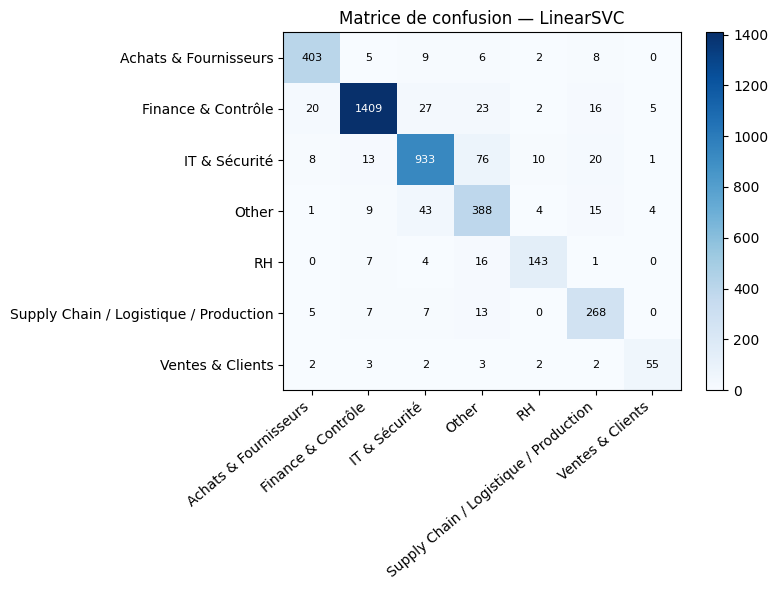

In [ ]:
if RUN_LINSVC:
    def make_svc():
        return LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE,
                         max_iter=4000)

    with timer("LinearSVC fit"):
        svc = make_svc()
        svc.fit(X_train_final, y_train, sample_weight=w_train)

    with timer("LinearSVC predict"):
        pred_svc = svc.predict(X_test_final)

    res_svc = evaluate_predictions(y_test, pred_svc, label_encoder, "LinearSVC")
    results.append(res_svc)


## 13. Modèle 3 — LightGBM sur sparse

Sans SVD : LightGBM ingère directement la matrice sparse.
Avec early stopping pour éviter le sur-apprentissage.

[LightGBM fit] 223.19s
[LightGBM predict] 0.68s
LightGBM  Macro-F1=0.8366  Weighted-F1=0.8811


,precision,recall,f1-score,support
Achats & Fournisseurs,0.919908,0.928406,0.924138,433.00000
Finance & Contrôle,0.957241,0.924101,0.940379,1502.00000
IT & Sécurité,0.875360,0.860509,0.867871,1061.00000
Other,0.708791,0.834052,0.766337,464.00000
RH,0.813333,0.713450,0.760125,171.00000
Supply Chain / Logistique / Production,0.848485,0.840000,0.844221,300.00000
Ventes & Clients,0.714286,0.797101,0.753425,69.00000
accuracy,0.879750,0.879750,0.879750,0.87975
macro avg,0.833915,0.842517,0.836642,4000.00000
weighted avg,0.884161,0.879750,0.881057,4000.00000


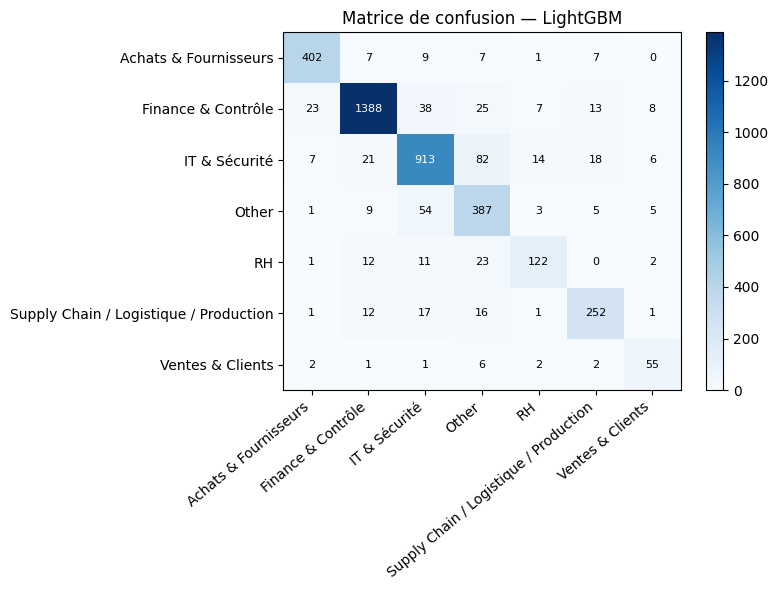

In [ ]:
if RUN_LIGHTGBM:
    def make_lgbm():
        return LGBMClassifier(
            objective="multiclass",
            n_estimators=800,
            learning_rate=0.05,
            num_leaves=127,
            min_child_samples=20,
            subsample=0.9,
            colsample_bytree=0.6,      # utile avec TF-IDF (nombreuses features)
            reg_lambda=1.0,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )

    # early stopping via eval_set interne
    X_tr2, X_val2, y_tr2, y_val2, w_tr2, w_val2 = train_test_split(
        X_train_final, y_train, w_train,
        test_size=0.15, random_state=RANDOM_STATE, stratify=y_train,
    )

    with timer("LightGBM fit"):
        lgbm = make_lgbm()
        try:
            from lightgbm import early_stopping, log_evaluation
            lgbm.fit(
                X_tr2, y_tr2, sample_weight=w_tr2,
                eval_set=[(X_val2, y_val2)],
                eval_metric="multi_logloss",
                callbacks=[early_stopping(30, verbose=False), log_evaluation(0)],
            )
        except ImportError:
            lgbm.fit(X_tr2, y_tr2, sample_weight=w_tr2)

    with timer("LightGBM predict"):
        pred_lgb = lgbm.predict(X_test_final)

    res_lgb = evaluate_predictions(y_test, pred_lgb, label_encoder, "LightGBM")
    results.append(res_lgb)


## 14. Évaluation CV stratifiée 5 folds

Pour une estimation plus stable des performances et de leur variance.
Le split train/test précédent est utilisé comme hold-out ; la CV est lancée
sur `X_train_final` uniquement.

In [ ]:
if RUN_CV:
    cv_results = []

    if RUN_LOGREG:
        print("\n--- CV LogisticRegression ---")
        cv_results.append(cv_evaluate(
            make_logreg, X_train_final, y_train,
            n_splits=N_FOLDS, sample_weight=w_train,
            model_name="LogReg", supports_sw=True,
        ))

    if RUN_LINSVC:
        print("\n--- CV LinearSVC ---")
        cv_results.append(cv_evaluate(
            make_svc, X_train_final, y_train,
            n_splits=N_FOLDS, sample_weight=w_train,
            model_name="LinearSVC", supports_sw=True,
        ))

    if RUN_LIGHTGBM:
        print("\n--- CV LightGBM (sans early stopping, plus lent) ---")
        def make_lgbm_cv():
            return LGBMClassifier(
                objective="multiclass", n_estimators=400,
                learning_rate=0.05, num_leaves=127, min_child_samples=20,
                subsample=0.9, colsample_bytree=0.6, reg_lambda=1.0,
                class_weight="balanced", random_state=RANDOM_STATE,
                n_jobs=-1, verbose=-1,
            )
        cv_results.append(cv_evaluate(
            make_lgbm_cv, X_train_final, y_train,
            n_splits=N_FOLDS, sample_weight=w_train,
            model_name="LightGBM", supports_sw=True,
        ))

    cv_df = pd.DataFrame(cv_results).sort_values("macro_mean", ascending=False)
    print("\n=== Résultats CV ===")
    print(cv_df.round(4))



--- CV LogisticRegression ---
  fold 1  macro=0.8113  weighted=0.8617
  fold 2  macro=0.8106  weighted=0.8612
  fold 3  macro=0.8173  weighted=0.8623
  fold 4  macro=0.8308  weighted=0.8660
  fold 5  macro=0.8363  weighted=0.8675
[LogReg] macro = 0.8213 ± 0.0105 | weighted = 0.8638 ± 0.0025

--- CV LinearSVC ---
  fold 1  macro=0.8294  weighted=0.8768
  fold 2  macro=0.8306  weighted=0.8776
  fold 3  macro=0.8351  weighted=0.8789
  fold 4  macro=0.8451  weighted=0.8804
  fold 5  macro=0.8554  weighted=0.8873
[LinearSVC] macro = 0.8391 ± 0.0098 | weighted = 0.8802 ± 0.0038

--- CV LightGBM (sans early stopping, plus lent) ---
  fold 1  macro=0.8304  weighted=0.8798
  fold 2  macro=0.8509  weighted=0.8909
  fold 3  macro=0.8395  weighted=0.8887
  fold 4  macro=0.8434  weighted=0.8849
  fold 5  macro=0.8555  weighted=0.8877
[LightGBM] macro = 0.8439 ± 0.0088 | weighted = 0.8864 ± 0.0038

=== Résultats CV ===
       model  macro_mean  macro_std  weighted_mean  weighted_std
2   LightGBM   

## 15. Comparaison des modèles (hold-out)

In [ ]:
results_df = pd.DataFrame([
    {"model": r["model"], "macro_f1": r["macro_f1"], "weighted_f1": r["weighted_f1"]}
    for r in results
]).sort_values("macro_f1", ascending=False).reset_index(drop=True)
print(results_df)


                model  macro_f1  weighted_f1
0           LinearSVC  0.869299     0.901017
1            LightGBM  0.836642     0.881057
2  LogisticRegression  0.834331     0.871882


## 15 bis. Réentraînement production sur les 20 000 lignes complètes

On choisit le modèle champion (CV en priorité), puis on **refit tout le pipeline** sur 100 % des données pour la version de production.

In [ ]:
def canonical_model_name(name: str) -> str:
    n = str(name).lower()
    if "light" in n or "lgb" in n:
        return "LightGBM"
    if "svc" in n:
        return "LinearSVC"
    if "log" in n:
        return "LogReg"
    raise ValueError(f"Modele non reconnu: {name}")

if FORCE_PROD_MODEL is not None:
    production_model_name = canonical_model_name(FORCE_PROD_MODEL)
elif PROD_SELECTION_SOURCE == "cv" and RUN_CV and "cv_results" in globals() and len(cv_results) > 0:
    cv_ref = pd.DataFrame(cv_results).sort_values("macro_mean", ascending=False).iloc[0]
    production_model_name = canonical_model_name(cv_ref["model"])
else:
    production_model_name = canonical_model_name(results_df.iloc[0]["model"])

print("Modele champion selectionne:", production_model_name)
print("Source de selection:", "cv" if (PROD_SELECTION_SOURCE == "cv" and RUN_CV and "cv_results" in globals()) else "holdout")

# 1) Full dataset (20 000 lignes)
X_full = df.drop(columns=[TARGET]).reset_index(drop=True)
y_full_label = df[TARGET].astype(str).reset_index(drop=True)
w_full = np.asarray(sample_weights_all, dtype=np.float32)
assert len(X_full) == len(w_full), "Desalignement X/weights"

final_label_encoder = LabelEncoder()
y_full = final_label_encoder.fit_transform(y_full_label)

# 2) Refit des representions sur 100% des donnees
with timer("PROD fit TF-IDF char (full)"):
    final_char_vec, Xfull_char, _, final_names_char = fit_text_matrix(
        X_full, X_full,
        cols=TEXT_COLS_CHAR,
        analyzer="char_wb",
        ngram_range=CHAR_NGRAMS,
        max_features=CHAR_MAX_FEATURES,
        use_hashing=USE_HASHING_FOR_SCALE,
    )

with timer("PROD fit TF-IDF word (full)"):
    final_word_vec, Xfull_word, _, final_names_word = fit_text_matrix(
        X_full, X_full,
        cols=TEXT_COLS_WORD,
        analyzer="word",
        ngram_range=WORD_NGRAMS,
        max_features=WORD_MAX_FEATURES,
        use_hashing=USE_HASHING_FOR_SCALE,
    )

with timer("PROD fit engineered/numeric/categorical (full)"):
    eng_full = build_engineered_features(X_full)
    if "ps_prefix" in eng_full.columns:
        eng_full = eng_full.drop(columns=["ps_prefix"])

    base_num_full = X_full[NUM_COLS].astype(np.float32)
    num_full_df = pd.concat([base_num_full.reset_index(drop=True),
                             eng_full.reset_index(drop=True)], axis=1)
    final_num_feat_names = list(num_full_df.columns)

    from sklearn.preprocessing import StandardScaler
    final_num_scaler = StandardScaler(with_mean=False)
    Xfull_num = csr_matrix(final_num_scaler.fit_transform(
        num_full_df.values.astype(np.float32)).astype(np.float32))

    cat_frame_full = X_full[CAT_COLS].copy()
    final_ohe = make_one_hot_encoder()
    Xfull_cat = final_ohe.fit_transform(cat_frame_full.astype(str))
    final_cat_feat_names = list(final_ohe.get_feature_names_out(cat_frame_full.columns))

X_full_final = hstack([Xfull_char, Xfull_word, Xfull_num, Xfull_cat]).tocsr()
final_char_feat = [f"char__{n}" for n in final_names_char]
final_word_feat = [f"word__{n}" for n in final_names_word]
final_feat_names = final_char_feat + final_word_feat + final_num_feat_names + final_cat_feat_names
assert X_full_final.shape[1] == len(final_feat_names), "Incoherence dimension full-data"

print("X_full_final:", X_full_final.shape)
print("Sparsity full: {:.4f}".format(1 - X_full_final.nnz / np.prod(X_full_final.shape)))

def build_production_model(model_name: str):
    if model_name == "LogReg":
        return LogisticRegression(
            C=2.0,
            max_iter=1000,
            class_weight="balanced",
            solver="lbfgs",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    if model_name == "LinearSVC":
        base = LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            max_iter=4000,
        )
        if CALIBRATE_LINSVC_FOR_PROD:
            try:
                return CalibratedClassifierCV(estimator=base, method="sigmoid", cv=N_FOLDS)
            except TypeError:
                return CalibratedClassifierCV(base_estimator=base, method="sigmoid", cv=N_FOLDS)
        return base
    if model_name == "LightGBM":
        return LGBMClassifier(
            objective="multiclass",
            n_estimators=800,
            learning_rate=0.05,
            num_leaves=127,
            min_child_samples=20,
            subsample=0.9,
            colsample_bytree=0.6,
            reg_lambda=1.0,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    raise ValueError(f"Modele unsupported pour la prod: {model_name}")

def safe_fit(model, X, y, sample_weight=None):
    if sample_weight is None:
        model.fit(X, y)
        return
    try:
        model.fit(X, y, sample_weight=sample_weight)
    except TypeError:
        model.fit(X, y)

production_model = build_production_model(production_model_name)
with timer("PROD fit final model (full)"):
    safe_fit(production_model, X_full_final, y_full, sample_weight=w_full)

production_is_calibrated = (production_model_name == "LinearSVC" and
                            CALIBRATE_LINSVC_FOR_PROD and
                            hasattr(production_model, "predict_proba"))
print("Modele de production entraine sur 100% des donnees.")
print("Calibration active:", production_is_calibrated)


Modele champion selectionne: LightGBM
Source de selection: cv
[PROD fit TF-IDF char (full)] 2.74s
[PROD fit TF-IDF word (full)] 10.30s
[PROD fit engineered/numeric/categorical (full)] 4.33s
X_full_final: (20000, 90963)
Sparsity full: 0.9978
[PROD fit final model (full)] 1836.12s
Modele de production entraine sur 100% des donnees.
Calibration active: False


## 15 ter. Score de confiance exploitable et audit manuel cible

Pour piloter la revue metier, on produit des probabilites calibrées (si champion = LinearSVC),
puis on construit une file de revue priorisee sur :
- `Other` predit
- les cas proches de la frontiere (marge faible)
- les classes rares.

In [ ]:
def get_probability_matrix(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        if scores.ndim == 1:
            scores = np.vstack([-scores, scores]).T
        scores = scores.astype(np.float64)
        scores = scores - scores.max(axis=1, keepdims=True)
        exp_scores = np.exp(scores)
        return exp_scores / exp_scores.sum(axis=1, keepdims=True)

    n_rows = X.shape[0]
    n_classes = len(final_label_encoder.classes_)
    return np.full((n_rows, n_classes), 1.0 / max(n_classes, 1), dtype=np.float64)

proba_full = get_probability_matrix(production_model, X_full_final)
rank_idx = np.argsort(proba_full, axis=1)[:, ::-1]
top1_idx = rank_idx[:, 0]
top2_idx = rank_idx[:, 1] if proba_full.shape[1] > 1 else rank_idx[:, 0]

pred_full_label = final_label_encoder.inverse_transform(top1_idx)
alt_full_label = final_label_encoder.inverse_transform(top2_idx)

top1_proba = proba_full[np.arange(len(proba_full)), top1_idx]
top2_proba = proba_full[np.arange(len(proba_full)), top2_idx]
confidence_margin = top1_proba - top2_proba
entropy = -np.sum(proba_full * np.log(np.clip(proba_full, 1e-12, 1.0)), axis=1)
entropy = entropy / np.log(max(proba_full.shape[1], 2))

confidence_band = np.select(
    [top1_proba < CONFIDENCE_LOW_THRESHOLD, top1_proba < CONFIDENCE_MED_THRESHOLD],
    ["low", "medium"],
    default="high",
)

trace_cols = [
    c for c in [
        "run_id", "asset_id", "technical_name", "source_ref",
        "column_names_text", "column_value_semantics_text",
    ] if c in df_gated.columns
]

scored_full_df = df_gated.reset_index(drop=True)[trace_cols].copy()
scored_full_df["y_true"] = y_full_label.values
scored_full_df["y_pred"] = pred_full_label
scored_full_df["y_pred_alt"] = alt_full_label
scored_full_df["confidence_score"] = top1_proba.astype(np.float32)
scored_full_df["confidence_margin"] = confidence_margin.astype(np.float32)
scored_full_df["uncertainty_entropy"] = entropy.astype(np.float32)
scored_full_df["confidence_band"] = confidence_band
scored_full_df["is_error"] = (scored_full_df["y_true"] != scored_full_df["y_pred"]).astype(np.int8)

class_ratio = y_full_label.value_counts(normalize=True)
rare_classes = sorted(class_ratio[class_ratio <= RARE_CLASS_MAX_RATIO].index.tolist())
print("Classes rares (ratio <=", RARE_CLASS_MAX_RATIO, "):", rare_classes)

scored_full_df["is_other_pred"] = scored_full_df["y_pred"].astype(str).str.lower().eq("other")
scored_full_df["is_borderline"] = scored_full_df["confidence_margin"] <= BORDERLINE_MARGIN_THRESHOLD
scored_full_df["is_rare_pred"] = scored_full_df["y_pred"].isin(rare_classes)
scored_full_df["is_rare_true"] = scored_full_df["y_true"].isin(rare_classes)

scored_full_df["review_priority"] = (
    60 * scored_full_df["is_other_pred"].astype(int)
    + 35 * scored_full_df["is_borderline"].astype(int)
    + 25 * scored_full_df["is_rare_pred"].astype(int)
    + 20 * scored_full_df["is_rare_true"].astype(int)
    + 15 * scored_full_df["is_error"].astype(int)
    + ((1.0 - scored_full_df["confidence_score"]) * 100).round(2)
)

target_mask = (
    scored_full_df["is_other_pred"]
    | scored_full_df["is_borderline"]
    | scored_full_df["is_rare_pred"]
    | scored_full_df["is_rare_true"]
)

audit_queue = scored_full_df[target_mask].sort_values(
    ["review_priority", "confidence_score"], ascending=[False, True]
).head(REVIEW_TOP_N).reset_index(drop=True)

audit_other = audit_queue[audit_queue["is_other_pred"]].copy()
audit_borderline = audit_queue[audit_queue["is_borderline"]].copy()
audit_rare = audit_queue[audit_queue["is_rare_pred"] | audit_queue["is_rare_true"]].copy()

review_output_dir = Path("artifacts_business_domain")
review_output_dir.mkdir(exist_ok=True)
scored_full_df.to_csv(review_output_dir / "full_scored_predictions.csv", index=False)
audit_queue.to_csv(review_output_dir / "manual_review_queue_targeted.csv", index=False)
audit_other.to_csv(review_output_dir / "manual_review_other.csv", index=False)
audit_borderline.to_csv(review_output_dir / "manual_review_borderline.csv", index=False)
audit_rare.to_csv(review_output_dir / "manual_review_rare_classes.csv", index=False)

print("\n=== Resume scoring / audit ===")
print("Modele production:", production_model_name)
print("Calibration active:", production_is_calibrated)
print("Total lignes scorees:", len(scored_full_df))
print("Queue audit ciblee:", len(audit_queue), "(top", REVIEW_TOP_N, ")")
print(" - Other predits:", int(audit_queue["is_other_pred"].sum()))
print(" - Proches frontiere:", int(audit_queue["is_borderline"].sum()))
print(" - Classes rares:", int((audit_queue["is_rare_pred"] | audit_queue["is_rare_true"]).sum()))

cols_preview = [
    c for c in [
        "technical_name", "source_ref", "y_true", "y_pred", "y_pred_alt",
        "confidence_score", "confidence_margin", "confidence_band",
        "is_other_pred", "is_borderline", "is_rare_pred", "is_error", "review_priority",
    ] if c in audit_queue.columns
]
audit_queue[cols_preview].head(30)


Classes rares (ratio <= 0.05 ): ['RH', 'Ventes & Clients']

=== Resume scoring / audit ===
Modele production: LightGBM
Calibration active: False
Total lignes scorees: 20000
Queue audit ciblee: 500 (top 500 )
 - Other predits: 500
 - Proches frontiere: 0
 - Classes rares: 0


,technical_name,source_ref,y_true,y_pred,y_pred_alt,confidence_score,confidence_margin,confidence_band,is_other_pred,is_borderline,is_rare_pred,is_error,review_priority
0,R_TFLT_CF2,PS_R_TFLT_CF2,Other,Other,IT & Sécurité,0.993229,0.986498,high,True,False,False,0,60.68
1,COMBO_SEL_11,PS_COMBO_SEL_11,Other,Other,IT & Sécurité,0.993453,0.986922,high,True,False,False,0,60.65
2,SYSADM.PS_COMBO_SEL_14,PS_COMBO_SEL_14,Other,Other,IT & Sécurité,0.993558,0.987145,high,True,False,False,0,60.64
3,SYSADM.PS_CA_BI_FF_TA5,PS_CA_BI_FF_TA5,Other,Other,Finance & Contrôle,0.994170,0.989523,high,True,False,False,0,60.58
4,NET_MANRQST_LNG,PS_NET_MANRQST_LNG,Other,Other,IT & Sécurité,0.994657,0.989488,high,True,False,False,0,60.53
5,SYSADM.PS_PTSF_CATPSFTSDL,PS_PTSF_CATPSFTSDL,Other,Other,IT & Sécurité,0.995660,0.991331,high,True,False,False,0,60.43
6,SYSADM.PS_IN_ITM_RECD_LST,PS_IN_ITM_RECD_LST,Other,Other,IT & Sécurité,0.995753,0.991697,high,True,False,False,0,60.42
7,SYSADM.PS_WM_CREWSCHD_REQ,PS_WM_CREWSCHD_REQ,Other,Other,Achats & Fournisseurs,0.995907,0.993043,high,True,False,False,0,60.41
8,SYSADM.PS_BI_WNHCC_TAO,PS_BI_WNHCC_TAO,Other,Other,Ventes & Clients,0.996055,0.992393,high,True,False,False,0,60.39
9,GM_IN_CONTAC_DT,PS_GM_IN_CONTAC_DT,Other,Other,RH,0.996205,0.992641,high,True,False,False,0,60.38


## 16. Analyse d'erreurs

On récupère le meilleur modèle et on inspecte les lignes mal prédites.

In [ ]:
best = max(results, key=lambda r: r["macro_f1"])
print("Meilleur modèle :", best["model"])

# On reconstruit les prédictions
if best["model"] == "LogisticRegression":
    best_pred = pred_lr
elif best["model"] == "LinearSVC":
    best_pred = pred_svc
else:
    best_pred = pred_lgb

X_test_original = X_test.reset_index(drop=True).copy()
X_test_original["y_true"] = label_encoder.inverse_transform(y_test)
X_test_original["y_pred"] = label_encoder.inverse_transform(best_pred)
X_test_original["is_error"] = (X_test_original["y_true"] != X_test_original["y_pred"]).astype(int)

errors = X_test_original[X_test_original["is_error"] == 1]
print(f"\nErreurs : {len(errors)} / {len(X_test_original)}"
      f" ({100*len(errors)/len(X_test_original):.2f}%)")

# Top confusions
conf_pairs = errors.groupby(["y_true", "y_pred"]).size().reset_index(name="n") \
                   .sort_values("n", ascending=False)
print("\n=== Top confusions ===")
print(conf_pairs.head(15))

print("\n=== Exemples d'erreurs ===")
cols_show = ["technical_name", "source_ref", "column_names_text",
             "column_value_semantics_text", "y_true", "y_pred"]
errors[cols_show].head(20)


Meilleur modèle : LinearSVC

Erreurs : 401 / 4000 (10.03%)

=== Top confusions ===
                                    y_true  \
13                           IT & Sécurité   
19                                   Other   
6                       Finance & Contrôle   
7                       Finance & Contrôle   
5                       Finance & Contrôle   
15                           IT & Sécurité   
9                       Finance & Contrôle   
25                                      RH   
21                                   Other   
12                           IT & Sécurité   
30  Supply Chain / Logistique / Production   
14                           IT & Sécurité   
1                    Achats & Fournisseurs   
18                                   Other   
11                           IT & Sécurité   

                                    y_pred   n  
13                                   Other  76  
19                           IT & Sécurité  43  
6                            IT &

,technical_name,source_ref,column_names_text,column_value_semantics_text,y_true,y_pred
16,sysadm ps proj txp typ lg,ps proj txp typ lg,debit credit descr descrshort effdt language c...,debit credit label descr label descrshort labe...,Finance & Contrôle,Other
34,pmt sec fields,ps pmt sec fields,pmt rule field id pmt sec field sw pmt securit...,pmt rule field id identifier pmt sec field sw ...,IT & Sécurité,Finance & Contrôle
36,eodi xfr reg,ps eodi xfr reg,descr eodi class id eodi package name eodi pat...,descr label eodi class id classification eodi ...,IT & Sécurité,Other
56,title tbl,ps title tbl,descr effdt eff status title,descr label effdt date or timestamp eff status...,RH,Other
72,conv dt tbl,ps conv dt tbl,begin depr dt begin dt calendar id convention ...,begin depr dt date or timestamp begin dt date ...,Finance & Contrôle,Other
76,sysadm ps ap search crit,ps ap search crit,fieldname label id search name,fieldname label label id label search name label,Finance & Contrôle,Other
80,pos treedefnlng,ps pos treedefnlng,descr effdt language cd setid tree name,descr label effdt date or timestamp language c...,IT & Sécurité,Other
91,sysadm ps fin attributes,ps fin attributes,attribute id descr descrlong enabled multiple ...,attribute id identifier descr label descrlong ...,Finance & Contrôle,Other
110,ap search reltd,ps ap search reltd,fieldname ref fieldname,fieldname label ref fieldname reference identi...,Finance & Contrôle,Other
134,sysadm ps fa fee tran lng,ps fa fee tran lng,descr language cd notes 254 setid transaction tbl,descr label language cd label notes 254 label ...,Finance & Contrôle,Other


## 17. Importance des variables (LightGBM)

Les top features sont majoritairement des n-grams TF-IDF.

                        feature  importance
78842           avg_data_length        2096
43248               word__label        1640
74594            word__varchar2        1456
2449                  char__ ps        1240
39531          word__identifier        1136
59053            word__quantity         884
39459         word__id varchar2         803
50988              word__number         797
78910     finance_keyword_count         755
38435                  word__id         748
2450                 char__ ps          746
78849                ratio_text         742
78835               field_count         738
78843           max_data_length         735
38877       word__id identifier         725
78856       log_avg_data_length         713
78840          text_field_count         646
78847             ratio_numeric         606
78837  non_nullable_field_count         591
23565      word__classification         530
11627                 char__ps          509
78859        technical_name_len 

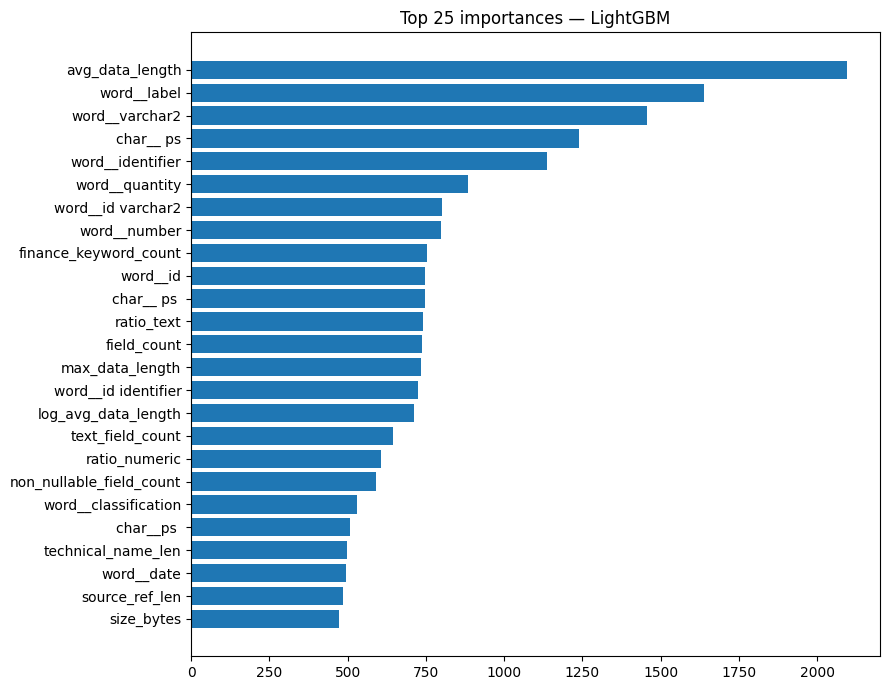


=== Importance totale par bloc ===
block
text_word             54606
text_char             23720
numeric_engineered    14319
categorical               0
Name: importance, dtype: int32


In [ ]:
if RUN_LIGHTGBM:
    imp = pd.DataFrame({
        "feature": all_feat_names,
        "importance": lgbm.feature_importances_,
    }).sort_values("importance", ascending=False)
    print(imp.head(30))

    # Top 25 visuel
    top = imp.head(25).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(top["feature"].astype(str), top["importance"])
    ax.set_title("Top 25 importances — LightGBM")
    plt.tight_layout()
    plt.show()

    # Répartition des importances par bloc
    def feat_block(name):
        if name.startswith("char__"): return "text_char"
        if name.startswith("word__"): return "text_word"
        if name in cat_feat_names:    return "categorical"
        return "numeric_engineered"
    imp["block"] = imp["feature"].map(feat_block)
    print("\n=== Importance totale par bloc ===")
    print(imp.groupby("block")["importance"].sum().sort_values(ascending=False))


## 18. Sauvegarde du pipeline

On sauvegarde tous les objets ajustés pour inférence ultérieure.

In [ ]:
OUTPUT_DIR = Path("artifacts_business_domain")
OUTPUT_DIR.mkdir(exist_ok=True)

# Priorite aux objets de production refittes sur 100% des donnees
active_label_encoder = final_label_encoder if "final_label_encoder" in globals() else label_encoder
active_char_vec = final_char_vec if "final_char_vec" in globals() else char_vec
active_word_vec = final_word_vec if "final_word_vec" in globals() else word_vec
active_ohe = final_ohe if "final_ohe" in globals() else ohe
active_num_scaler = final_num_scaler if "final_num_scaler" in globals() else num_scaler
active_feature_names = final_feat_names if "final_feat_names" in globals() else all_feat_names
active_num_feature_names = final_num_feat_names if "final_num_feat_names" in globals() else num_feat_names
active_prod_model_name = production_model_name if "production_model_name" in globals() else results_df.iloc[0]["model"]
active_prod_model = production_model if "production_model" in globals() else None
active_prod_is_calibrated = bool(production_is_calibrated) if "production_is_calibrated" in globals() else False

artifacts = {
    "label_encoder": active_label_encoder,
    "char_vectorizer": active_char_vec,
    "word_vectorizer": active_word_vec,
    "one_hot_encoder": active_ohe,
    "num_scaler": active_num_scaler,
    "production_model_name": active_prod_model_name,
    "production_model_calibrated": active_prod_is_calibrated,
    "config": {
        "TARGET": TARGET,
        "DROP_COLS": DROP_COLS,
        "TEXT_COLS_CHAR": TEXT_COLS_CHAR,
        "TEXT_COLS_WORD": TEXT_COLS_WORD,
        "NUM_COLS": NUM_COLS,
        "CAT_COLS": CAT_COLS,
        "CHAR_MAX_FEATURES": CHAR_MAX_FEATURES,
        "WORD_MAX_FEATURES": WORD_MAX_FEATURES,
        "CHAR_NGRAMS": CHAR_NGRAMS,
        "WORD_NGRAMS": WORD_NGRAMS,
        "USE_CONSENSUS_AS_WEIGHT": USE_CONSENSUS_AS_WEIGHT,
        "MIN_CONSENSUS_FILTER": MIN_CONSENSUS_FILTER,
        "CONFIDENCE_LOW_THRESHOLD": CONFIDENCE_LOW_THRESHOLD,
        "CONFIDENCE_MED_THRESHOLD": CONFIDENCE_MED_THRESHOLD,
        "BORDERLINE_MARGIN_THRESHOLD": BORDERLINE_MARGIN_THRESHOLD,
        "RARE_CLASS_MAX_RATIO": RARE_CLASS_MAX_RATIO,
    },
    "feature_names": active_feature_names,
    "numeric_feature_names": active_num_feature_names,
    "cat_columns": CAT_COLS,
    "domain_keywords": DOMAIN_KEYWORDS,
    "ps_module_prefixes": PS_MODULE_PREFIXES,
}

if active_prod_model is not None:
    artifacts["production_model"] = active_prod_model

# On conserve aussi les modeles du benchmark hold-out si disponibles
if RUN_LOGREG and "logreg" in globals():
    artifacts["logreg_model"] = logreg
if RUN_LINSVC and "svc" in globals():
    artifacts["linsvc_model"] = svc
if RUN_LIGHTGBM and "lgbm" in globals():
    artifacts["lightgbm_model"] = lgbm

joblib.dump(artifacts, OUTPUT_DIR / "business_domain_pipeline.joblib", compress=3)
results_df.to_csv(OUTPUT_DIR / "model_comparison_holdout.csv", index=False)
if RUN_CV and "cv_results" in globals():
    pd.DataFrame(cv_results).to_csv(OUTPUT_DIR / "model_comparison_cv.csv", index=False)

print("Artefacts sauvegardes dans :", OUTPUT_DIR.resolve())
print("Fichiers:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(" -", p.name)


Artefacts sauvegardes dans : C:\Users\Salem\Desktop\Projets\pfe\Projet\LLM\artifacts_business_domain
Fichiers:
 - business_domain_pipeline.joblib
 - business_domain_pipeline_artifacts.joblib
 - full_scored_predictions.csv
 - manual_review_borderline.csv
 - manual_review_other.csv
 - manual_review_queue_targeted.csv
 - manual_review_rare_classes.csv
 - model_comparison.csv
 - model_comparison_cv.csv
 - model_comparison_holdout.csv


## 19. Fonction d'inférence réutilisable

Template pour réappliquer le pipeline sur de nouvelles données, en
rechargeant les artefacts.

In [ ]:
def predict_business_domain(df_new: pd.DataFrame, artifacts: dict,
                            model_key: str = None,
                            return_confidence: bool = True):
    """Applique le pipeline entraine sur un nouveau DataFrame.

    Args:
        df_new : DataFrame avec les memes colonnes source que l'entrainement.
        artifacts : dict charge via joblib.load(...).
        model_key : nom du modele a utiliser. Si None, prend production_model
                    puis fallback vers lightgbm/logreg/linsvc.
        return_confidence : si True, retourne aussi les scores de confiance.
    """
    cfg = artifacts["config"]
    le = artifacts["label_encoder"]
    char_vec = artifacts["char_vectorizer"]
    word_vec = artifacts["word_vectorizer"]
    ohe = artifacts["one_hot_encoder"]
    num_scaler = artifacts["num_scaler"]

    # Drop fuites / ids si presents
    present_drop = [c for c in cfg["DROP_COLS"] if c in df_new.columns]
    df_new = df_new.drop(columns=present_drop)

    # Preparation identique
    df_p = prepare_dataframe(df_new)

    # Text
    char_txt = df_p[cfg["TEXT_COLS_CHAR"]].fillna("").astype(str).agg(" ".join, axis=1)
    word_txt = df_p[cfg["TEXT_COLS_WORD"]].fillna("").astype(str).agg(" ".join, axis=1)
    X_char = char_vec.transform(char_txt)
    X_word = word_vec.transform(word_txt)

    # Engineered + numeric
    eng = build_engineered_features(df_p)
    if "ps_prefix" in eng.columns:
        eng = eng.drop(columns=["ps_prefix"])
    num_df = pd.concat([df_p[cfg["NUM_COLS"]].astype(np.float32).reset_index(drop=True),
                        eng.reset_index(drop=True)], axis=1)
    X_num = csr_matrix(num_scaler.transform(num_df.values.astype(np.float32)).astype(np.float32))

    # Categorielles
    cat_frame = df_p[cfg["CAT_COLS"]].copy()
    X_cat = ohe.transform(cat_frame.astype(str))

    X_all = hstack([X_char, X_word, X_num, X_cat]).tocsr()

    if model_key is not None:
        model = artifacts[model_key]
    elif "production_model" in artifacts:
        model = artifacts["production_model"]
    elif "lightgbm_model" in artifacts:
        model = artifacts["lightgbm_model"]
    elif "logreg_model" in artifacts:
        model = artifacts["logreg_model"]
    elif "linsvc_model" in artifacts:
        model = artifacts["linsvc_model"]
    else:
        raise KeyError("Aucun modele trouve dans artifacts")

    # Probabilites / scores de confiance
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_all)
    elif hasattr(model, "decision_function"):
        raw_scores = model.decision_function(X_all)
        if raw_scores.ndim == 1:
            raw_scores = np.vstack([-raw_scores, raw_scores]).T
        raw_scores = raw_scores.astype(np.float64)
        raw_scores = raw_scores - raw_scores.max(axis=1, keepdims=True)
        exp_scores = np.exp(raw_scores)
        proba = exp_scores / exp_scores.sum(axis=1, keepdims=True)
    else:
        n_rows = X_all.shape[0]
        n_classes = len(le.classes_)
        proba = np.full((n_rows, n_classes), 1.0 / max(n_classes, 1), dtype=np.float64)

    rank_idx = np.argsort(proba, axis=1)[:, ::-1]
    top1_idx = rank_idx[:, 0]
    top2_idx = rank_idx[:, 1] if proba.shape[1] > 1 else rank_idx[:, 0]

    y_pred = le.inverse_transform(top1_idx)
    y_pred_alt = le.inverse_transform(top2_idx)
    top1 = proba[np.arange(len(proba)), top1_idx]
    top2 = proba[np.arange(len(proba)), top2_idx]
    margin = top1 - top2

    low_thr = cfg.get("CONFIDENCE_LOW_THRESHOLD", 0.60)
    med_thr = cfg.get("CONFIDENCE_MED_THRESHOLD", 0.80)
    confidence_band = np.select(
        [top1 < low_thr, top1 < med_thr],
        ["low", "medium"],
        default="high",
    )

    if not return_confidence:
        return y_pred, X_all

    confidence_df = pd.DataFrame({
        "y_pred": y_pred,
        "y_pred_alt": y_pred_alt,
        "confidence_score": top1.astype(np.float32),
        "confidence_margin": margin.astype(np.float32),
        "confidence_band": confidence_band,
    })
    return y_pred, X_all, confidence_df

print("Fonction predict_business_domain definie. Exemple :")
print("  artifacts = joblib.load('artifacts_business_domain/business_domain_pipeline.joblib')")
print("  preds, _, conf = predict_business_domain(df_new, artifacts)")
print("  conf[['y_pred', 'confidence_score', 'confidence_band']].head()")


Fonction predict_business_domain definie. Exemple :
  artifacts = joblib.load('artifacts_business_domain/business_domain_pipeline.joblib')
  preds, _, conf = predict_business_domain(df_new, artifacts)
  conf[['y_pred', 'confidence_score', 'confidence_band']].head()


## 20. Notes pour passer à ~500 000 lignes

### Ce qui tient tel quel
- TF-IDF sparse + LogReg/LinearSVC/LightGBM sur sparse → linéaire en n, OK.
- `StratifiedKFold` → OK.
- Estimation mémoire : TF-IDF combiné ~130 k features × 500 k lignes,
  densité ~0.1 % → matrice sparse ≈ 2-3 GB. Gérable si 8 GB RAM.

### Ce qu'il faut changer
1. **Lecture CSV** : activer `chunksize=50_000` dans `pd.read_csv`, ou convertir
   le CSV en Parquet une fois pour toutes (`df.to_parquet(..., compression='snappy')`).
2. **Vectoriseurs** : si mémoire limite, passer `USE_HASHING_FOR_SCALE=True`
   (HashingVectorizer, mémoire fixe, pas besoin de stocker le vocabulaire).
3. **LightGBM** : garder `colsample_bytree=0.5–0.6`, `n_estimators=400` + early stopping,
   passer en `device='gpu'` si dispo. Sinon utiliser `bagging_fraction=0.8`.
4. **CV** : réduire `N_FOLDS=3` pour itération rapide, revenir à 5 en final.
5. **Audit qualité labels** : le filtrage `MIN_CONSENSUS_FILTER` devient plus
   intéressant sur 500 k (on peut se permettre de retirer les lignes douteuses).
6. **Parallélisation** : `n_jobs=-1` sur `LogisticRegression` (solver='saga'),
   sur `LGBMClassifier`, sur `train_test_split` (pas besoin, c'est rapide).

### Exemple de chargement mémoire-efficient
```python
dtypes = {...}  # celui défini plus haut
usecols = [c for c in ALL_NEEDED_COLS]
chunks = []
for chunk in pd.read_csv(DATA_PATH, dtype=dtypes, usecols=usecols, chunksize=50_000):
    chunks.append(chunk)
df_raw = pd.concat(chunks, ignore_index=True)
```


## Récapitulatif des améliorations

| Catégorie          | Avant                                    | Après                                                                   |
|--------------------|------------------------------------------|-------------------------------------------------------------------------|
| Fuites             | `business_domain_raw`, `llm_*` présents  | Exclus explicitement (`LEAK_COLS`)                                      |
| Qualité labels     | Aucun traitement                         | Filtrage + pondération par `llm_consensus_score`                        |
| Features texte     | TF-IDF → SVD 50-60 comp.                 | TF-IDF sparse direct (sans SVD), vocab étendu, fallback HashingVectorizer |
| Features métier    | Keywords EN basiques                     | Keywords EN + FR + préfixes PeopleSoft (GL, HR, PO, ...)                  |
| Features techniques| Quelques ratios                          | Ratios + logs + shape-features + préfixes extraits                      |
| Modèles            | LinearSVC / LightGBM / CatBoost          | LogisticRegression + LinearSVC + LightGBM (CatBoost retiré : lent, gain marginal) |
| Évaluation         | Split 80/20 unique                       | Split + CV stratifiée 5 folds (moyenne ± écart-type)                    |
| Pondération classes| `class_weight='balanced'`                | idem + `sample_weight` = consensus LLM                                  |
| Early stopping     | Non                                      | LightGBM : 30 rounds patience                                           |
| Scalabilité        | Non adressée                             | dtypes optimisés, HashingVectorizer optionnel, chunking documenté       |
| Reproductibilité   | Path Windows hardcodé                    | Résolution multi-plateforme                                             |
